<a href="https://colab.research.google.com/github/pmatkowska94/MSC_Data_Science/blob/main/CHO_seq%2BRNN_model_cross_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import joblib

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_df.csv to test_df.csv
Saving train_aug.csv to train_aug.csv
Saving val_df.csv to val_df.csv


In [ ]:
train_aug = pd.read_csv('train_aug.csv')
test_df = pd.read_csv('test_df.csv')
val_df = pd.read_csv('val_df.csv')

In [ ]:
colours = {
    'hist_bar': '#4C9F70',
    'line_exp': '#1B9E77',
    'line_model': '#377EB8',
    'ci_fill': '#A6CEE3',
    'axes': '#333333',
    'grid': '#E5E5E5',
    'background': '#FFFFFF',
    'text': '#222222'}

In [ ]:
plt.rcParams.update({
    'figure.facecolor': colours['background'],
    'axes.facecolor': colours['background'],
    'axes.edgecolor': colours['axes'],
    'axes.labelcolor': colours['text'],
    'xtick.color': colours['text'],
    'ytick.color': colours['text'],
    'grid.color': colours['grid'],
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'text.color': colours['text'],
    'axes.titlecolor': colours['text']})

In [ ]:
sns.set_style('whitegrid', {
    'axes.facecolor': '#FFFFFF',
    'grid.color': '#E5E5E5',
    'axes.edgecolor': '#333333',
    'text.color': '#222222' })

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving scaler_combined_cho_ipsc_main_study.pkl to scaler_combined_cho_ipsc_main_study.pkl


In [ ]:
scaler = joblib.load("scaler_combined_cho_ipsc_main_study.pkl")

In [ ]:
train_aug.drop(columns='cell_type', inplace=True)
val_df.drop(columns='cell_type', inplace=True)
test_df.drop(columns='cell_type', inplace=True)

In [ ]:
group_cols = ['p_id', 'r_id', 'clone_id', 'group_volume', 'group_id']
feature_cols = [col for col in train_aug.columns if col not in group_cols]

In [ ]:
def build_ar_sequences(df, group_cols, feature_cols, seed_col='seed_d', vcd_col='vcd'):
    X_list, y_list = [], []
    df_sorted = df.sort_values(group_cols + ['time'])
    other_cols = [c for c in feature_cols if c != vcd_col]

    for _, g in df_sorted.groupby(group_cols, sort=False):
        g = g.reset_index(drop=True)
        v = g[vcd_col].to_numpy().astype('float32')
        seed = g[seed_col].iloc[0]
        v_prev = np.concatenate([[seed], v[:-1]]).astype('float32')
        other = g[other_cols].to_numpy().astype('float32')
        X = np.concatenate([other, v_prev[:, None]], axis=1)
        y = v[:, None]
        X_list.append(X)
        y_list.append(y)
    return X_list, y_list

In [ ]:
ar_X_train, ar_y_train = build_ar_sequences(train_aug, group_cols, feature_cols)
ar_X_val,   ar_y_val   = build_ar_sequences(val_df,    group_cols, feature_cols)
ar_X_test,  ar_y_test  = build_ar_sequences(test_df,   group_cols, feature_cols)

In [ ]:
for i, (x_seq, y_seq) in enumerate(zip(ar_X_train, ar_y_train)):
    print(f"X shape = {x_seq.shape}, y shape = {y_seq.shape}")

X shape = (11, 11), y shape = (11, 1)
X shape = (11, 11), y shape = (11, 1)
X shape = (11, 11), y shape = (11, 1)
X shape = (9, 11), y shape = (9, 1)
X shape = (9, 11), y shape = (9, 1)
X shape = (9, 11), y shape = (9, 1)
X shape = (9, 11), y shape = (9, 1)
X shape = (9, 11), y shape = (9, 1)
X shape = (9, 11), y shape = (9, 1)
X shape = (10, 11), y shape = (10, 1)
X shape = (10, 11), y shape = (10, 1)
X shape = (10, 11), y shape = (10, 1)
X shape = (9, 11), y shape = (9, 1)
X shape = (9, 11), y shape = (9, 1)
X shape = (9, 11), y shape = (9, 1)
X shape = (11, 11), y shape = (11, 1)
X shape = (11, 11), y shape = (11, 1)
X shape = (11, 11), y shape = (11, 1)
X shape = (10, 11), y shape = (10, 1)
X shape = (10, 11), y shape = (10, 1)
X shape = (10, 11), y shape = (10, 1)
X shape = (11, 11), y shape = (11, 1)
X shape = (11, 11), y shape = (11, 1)
X shape = (11, 11), y shape = (11, 1)
X shape = (10, 11), y shape = (10, 1)
X shape = (10, 11), y shape = (10, 1)
X shape = (10, 11), y shape = 

In [ ]:
def trim_pad(X_list, y_list, max_len, pad):
    X_list = [x[:max_len, :] for x in X_list]
    y_list = [np.asarray(y, dtype='float32')[:max_len].reshape(-1, 1) for y in y_list]

    X = tf.ragged.constant(X_list).to_tensor(default_value=pad,shape=[None,max_len, X_list[0].shape[1]])
    y = tf.ragged.constant(y_list).to_tensor(default_value=pad,shape=[None, max_len, 1])
    return X, y

In [ ]:
max_len = 14
pad = -2.0

X_train, y_train = trim_pad(ar_X_train, ar_y_train, max_len, pad)
X_val,   y_val   = trim_pad(ar_X_val,   ar_y_val,   max_len, pad)
X_test,  y_test  = trim_pad(ar_X_test,  ar_y_test,  max_len, pad)

In [ ]:
X_train, y_train = X_train.numpy(), y_train.numpy()
X_val,   y_val   = X_val.numpy(),   y_val.numpy()
X_test,  y_test  = X_test.numpy(),  y_test.numpy()

In [ ]:
print(y_train.shape)

(252, 14, 1)


In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_test.shape)

(252, 14, 11)
(17, 14, 11)
(17, 14, 1)


In [ ]:
def build_sample_weights(y, pad_value=-2.0, k=1):
    y2 = np.squeeze(y, axis=-1)
    valid = (y2 != pad_value)
    T = y2.shape[1]
    after_k = np.arange(T)[None, :] >= k
    return (valid & after_k).astype('float32')

sw_train = build_sample_weights(y_train, pad, k=1)
sw_val   = build_sample_weights(y_val,   pad, k=1)
sw_test  = build_sample_weights(y_test,  pad, k=1)

In [ ]:
timesteps = X_train.shape[1]
n_features = X_train.shape[2]

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving model_main_study_tl1_low_LR.keras to model_main_study_tl1_low_LR.keras


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('model_main_study_tl1_low_LR.keras')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 14, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 14, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 14, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 14, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 14, 32)         │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 14, 64)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14, 1)          │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,557 (248.27 KB)

 Trainable params: 14,657 (57.25 KB)

 Non-trainable params: 19,584 (76.50 KB)

 Optimizer params: 29,316 (114.52 KB)

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
model.evaluate(X_test, y_test, sample_weight=sw_test)
predicted_vcd = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0214 - mae: 0.5872
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 996ms/step


In [ ]:
valid = (y_test[..., 0] != pad)

for i in range(predicted_vcd.shape[0]):
    idx = np.where(valid[i])[0]
    if idx.size:
        j = idx[0]
        predicted_vcd[i, j, 0] = y_test[i, j, 0]

predicted_vcd = predicted_vcd.squeeze(-1)
y_test = y_test.squeeze(-1)

In [ ]:
n_samples, time_steps = predicted_vcd.shape
vcd_idx = list(scaler.feature_names_in_).index('vcd')

flat_pred = predicted_vcd.flatten()
flat_true = y_test.flatten()

dummy_pred = np.zeros((n_samples * time_steps, len(scaler.feature_names_in_)))
dummy_true = np.zeros_like(dummy_pred)

dummy_pred[:, vcd_idx] = flat_pred
dummy_true[:, vcd_idx] = flat_true

inv_pred = scaler.inverse_transform(dummy_pred)[:, vcd_idx]
inv_true = scaler.inverse_transform(dummy_true)[:, vcd_idx]

vcd_pred_original = inv_pred.reshape(n_samples, time_steps)
vcd_true_original = inv_true.reshape(n_samples, time_steps)

/tmp/ipython-input-4242884973.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


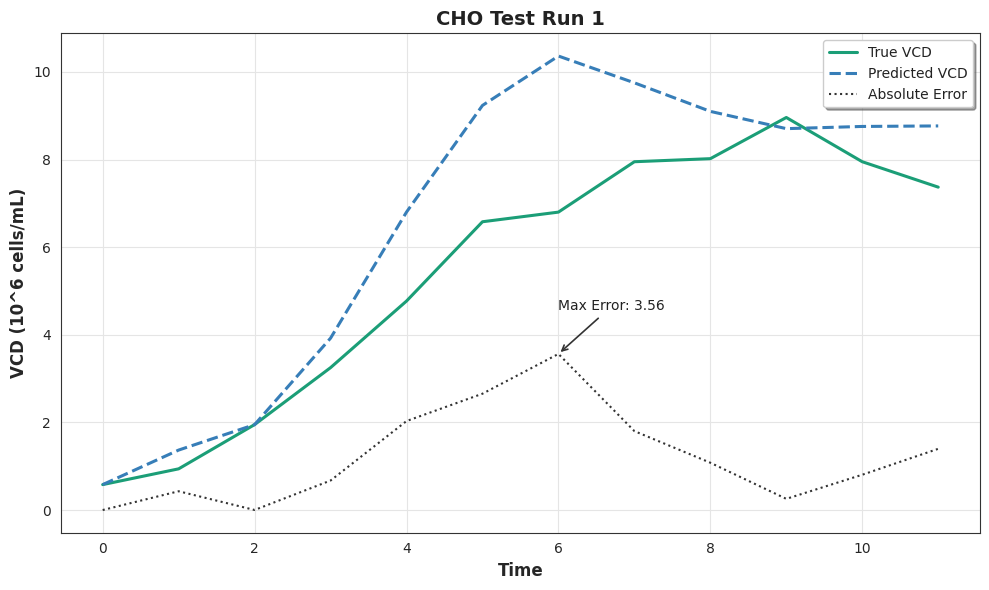

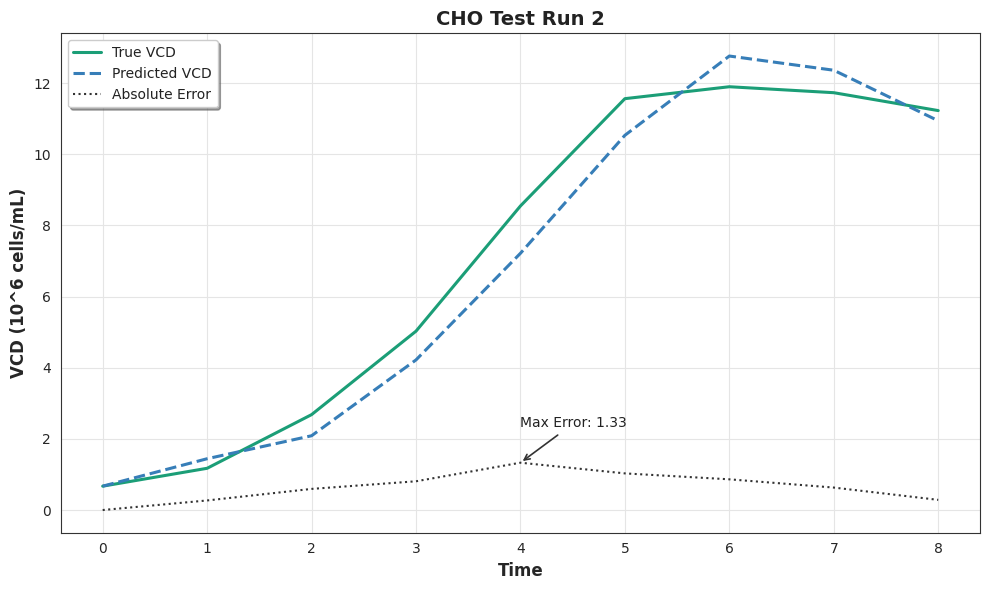

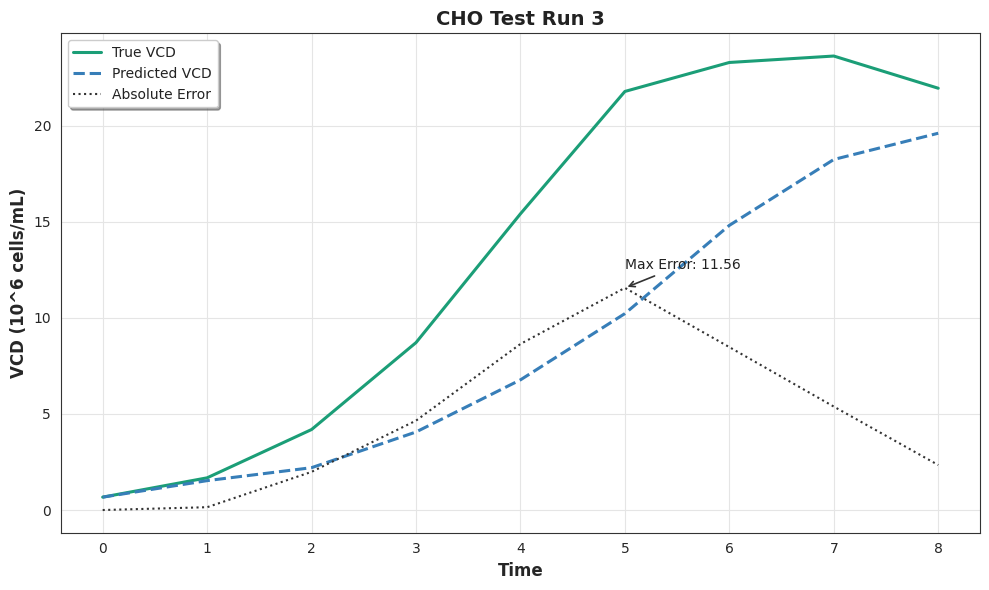

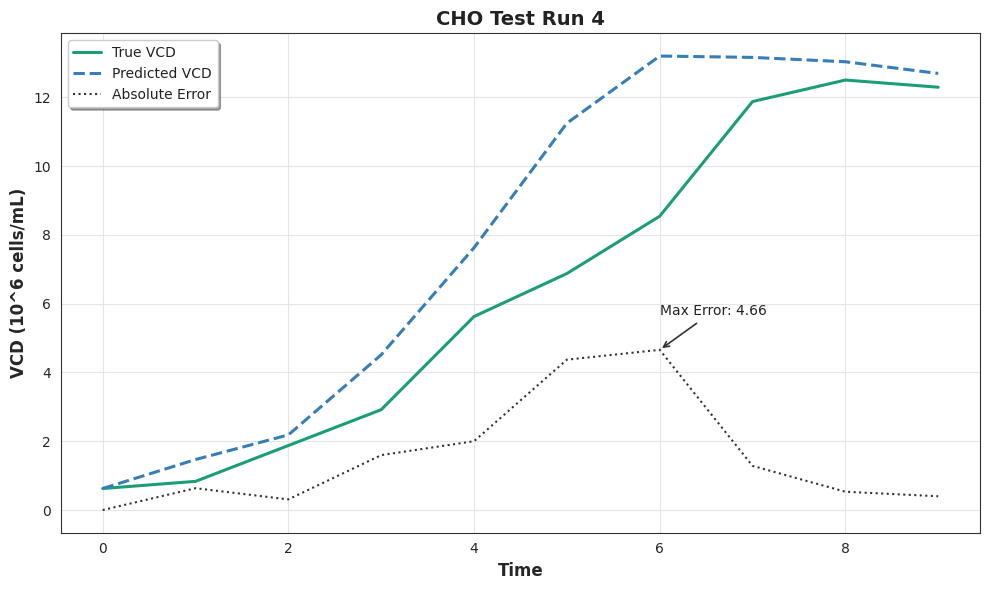

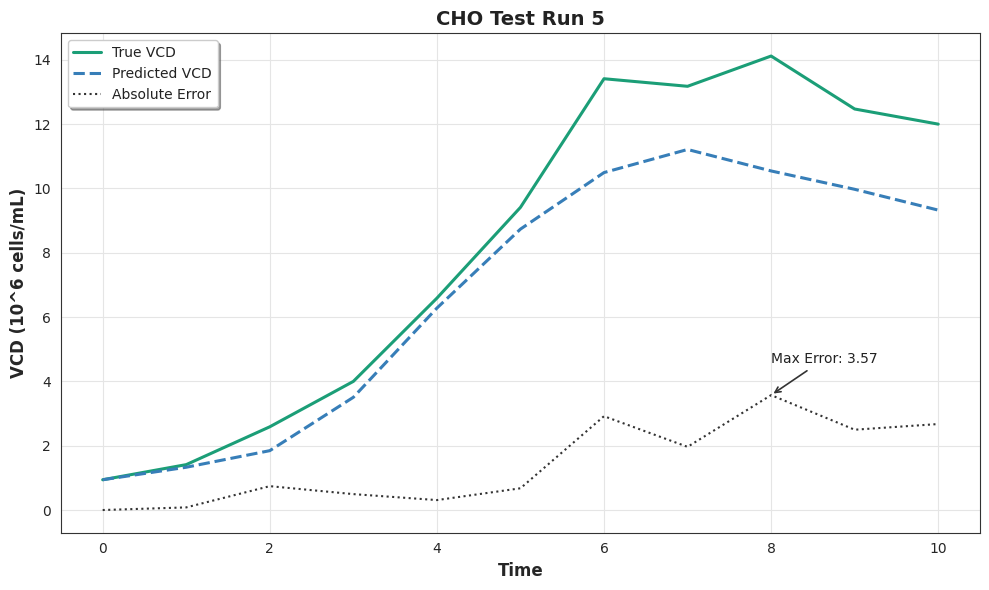

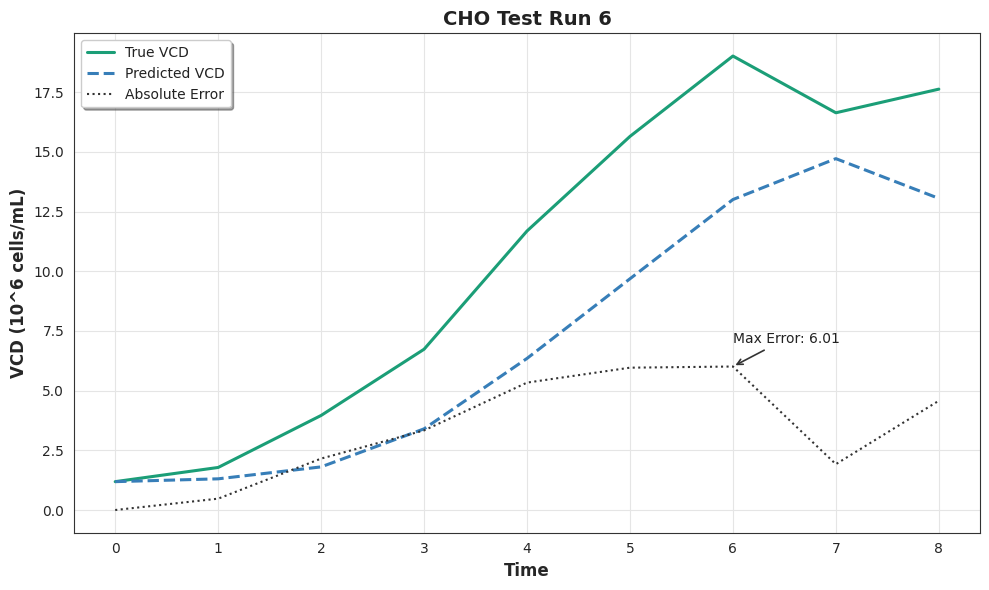

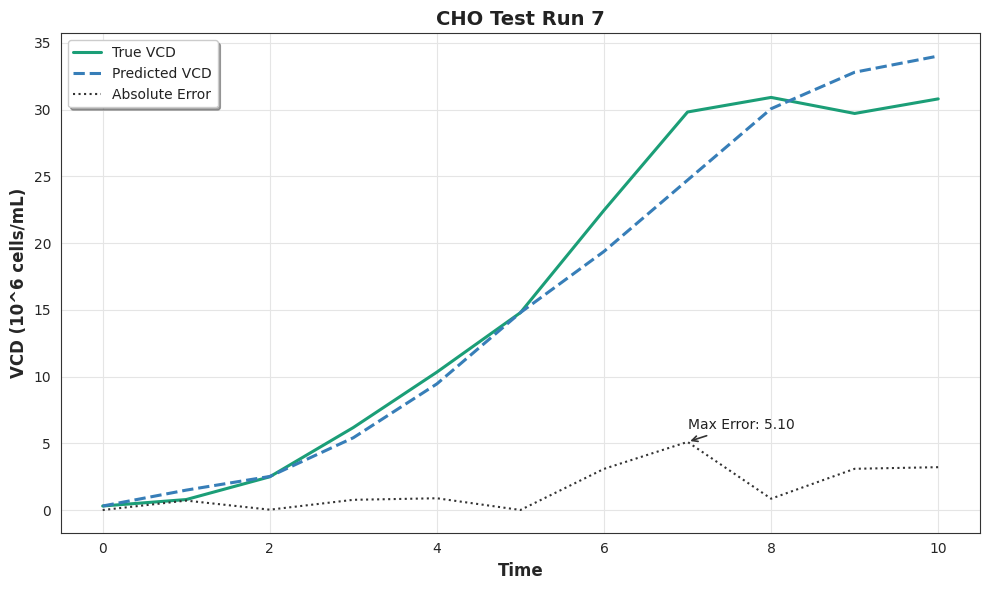

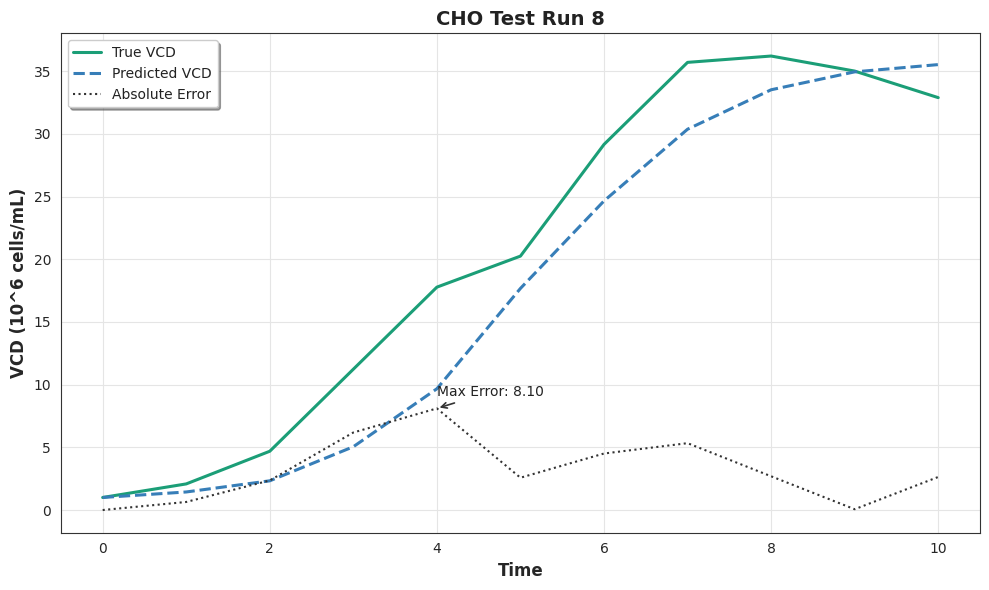

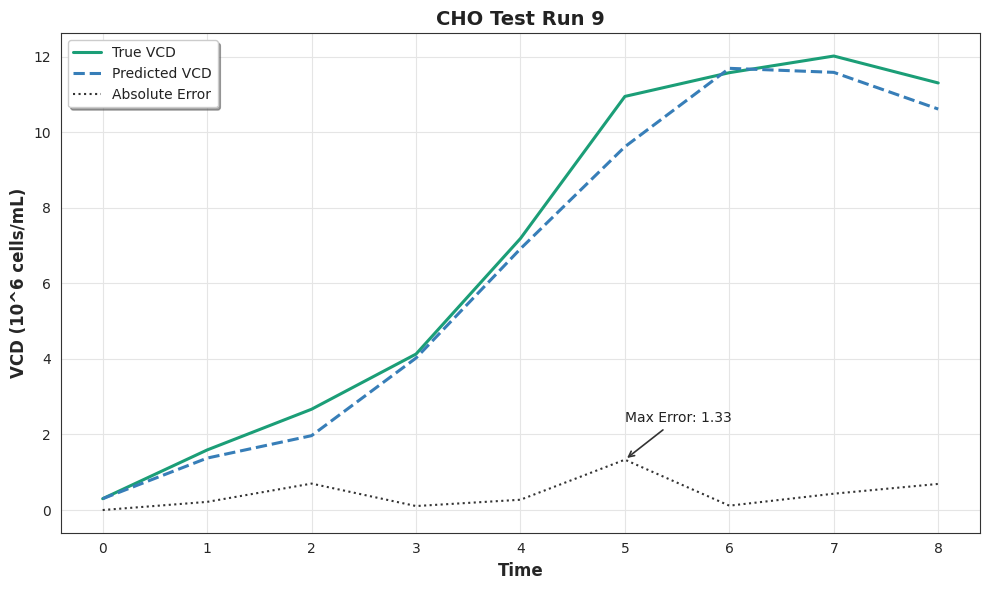

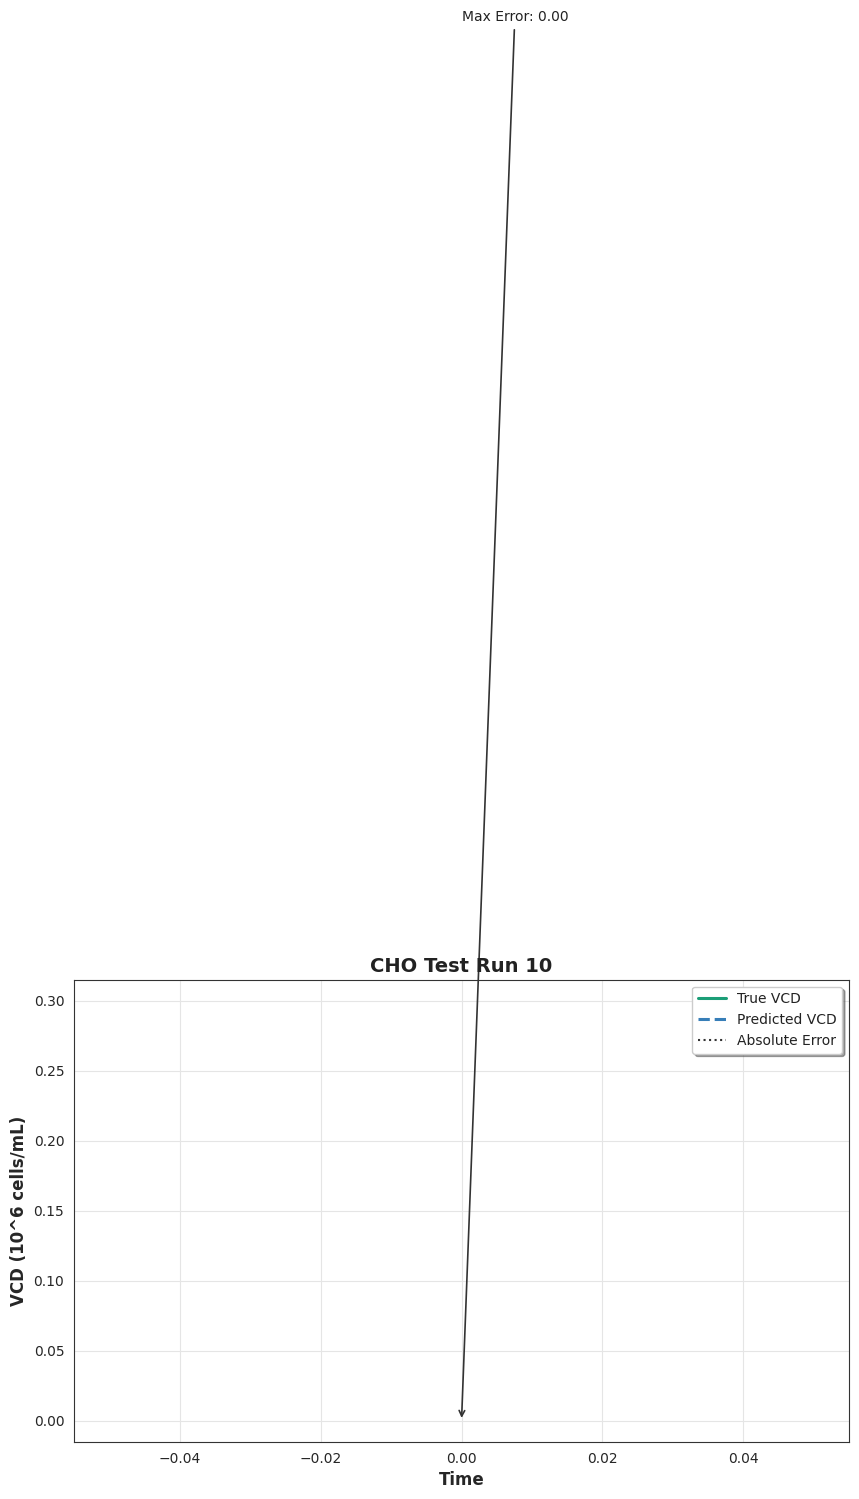

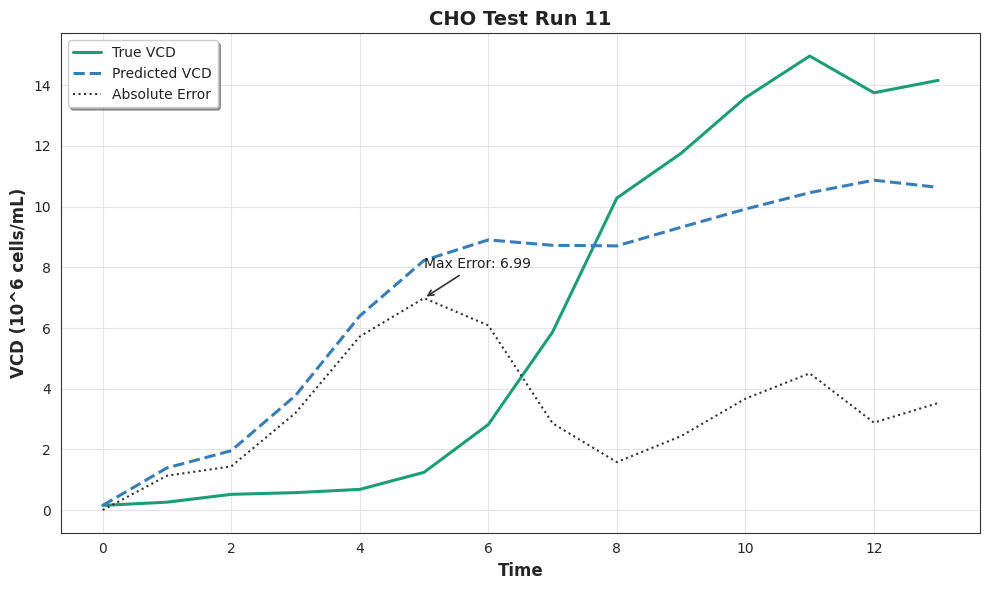

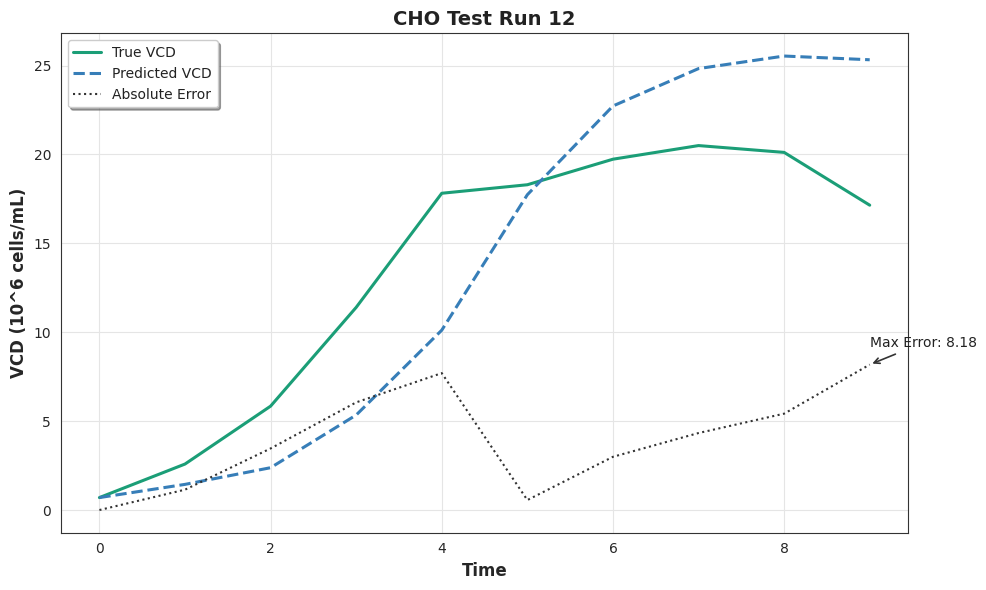

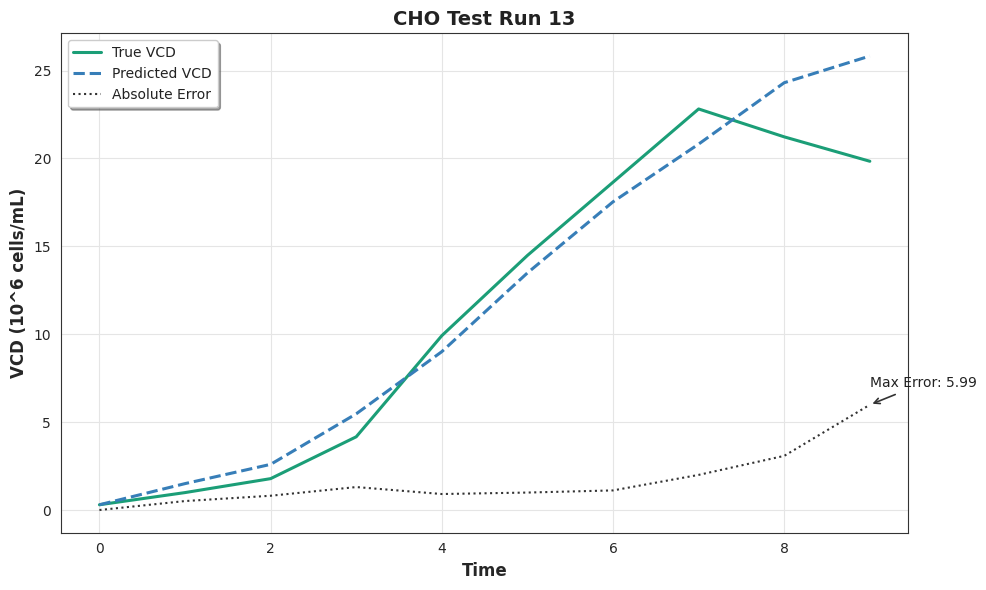

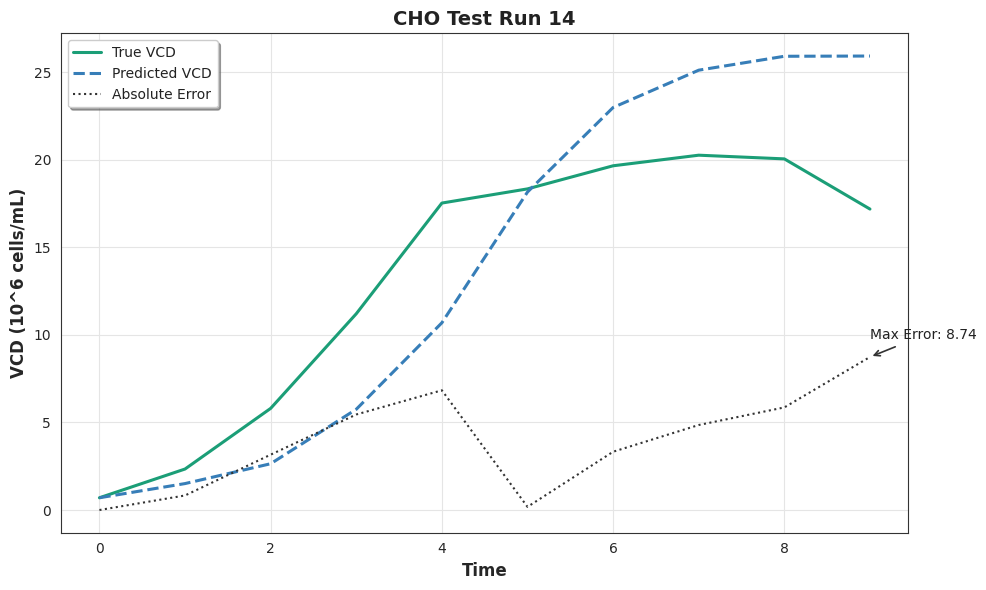

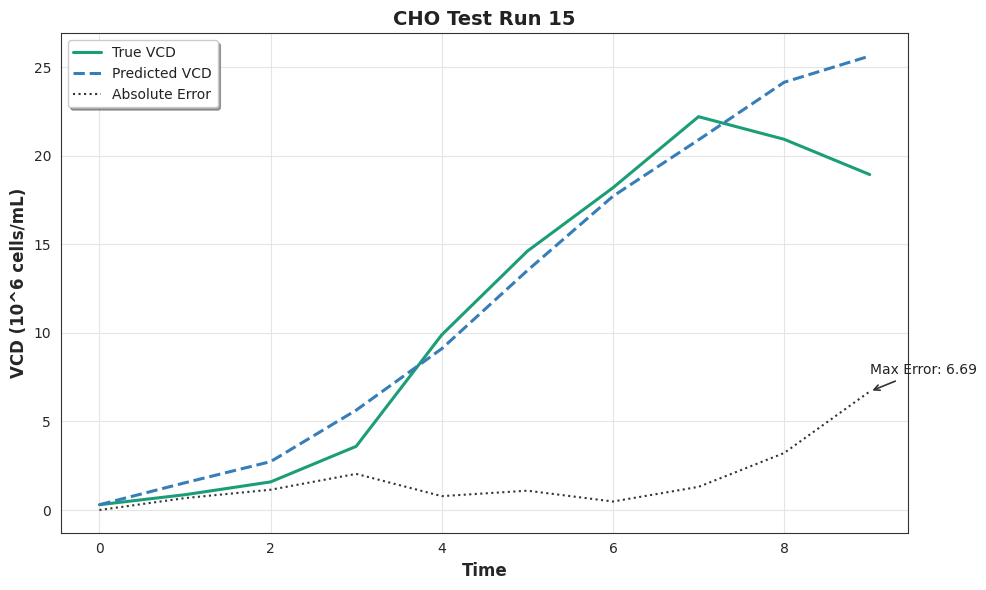

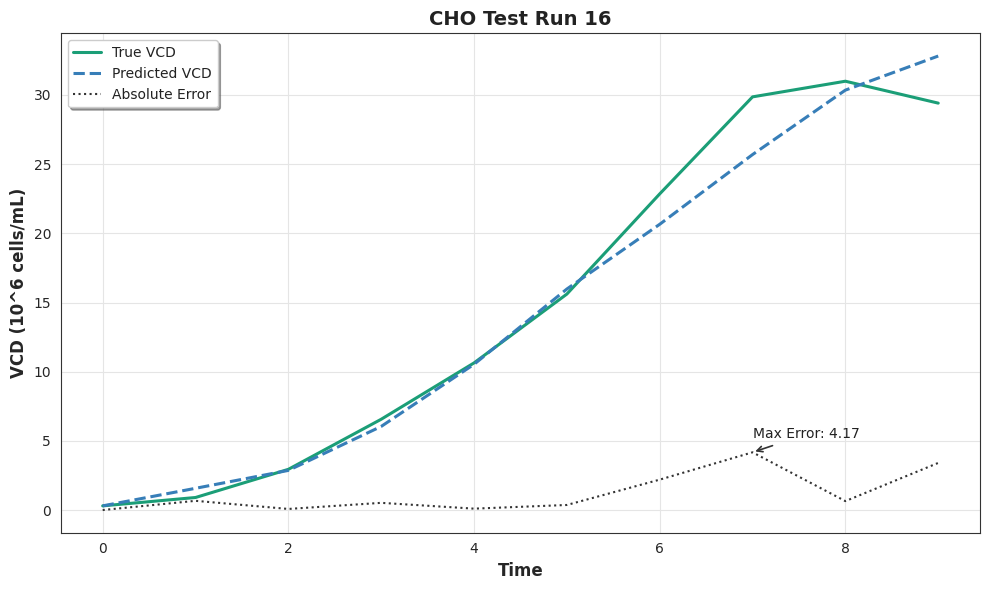

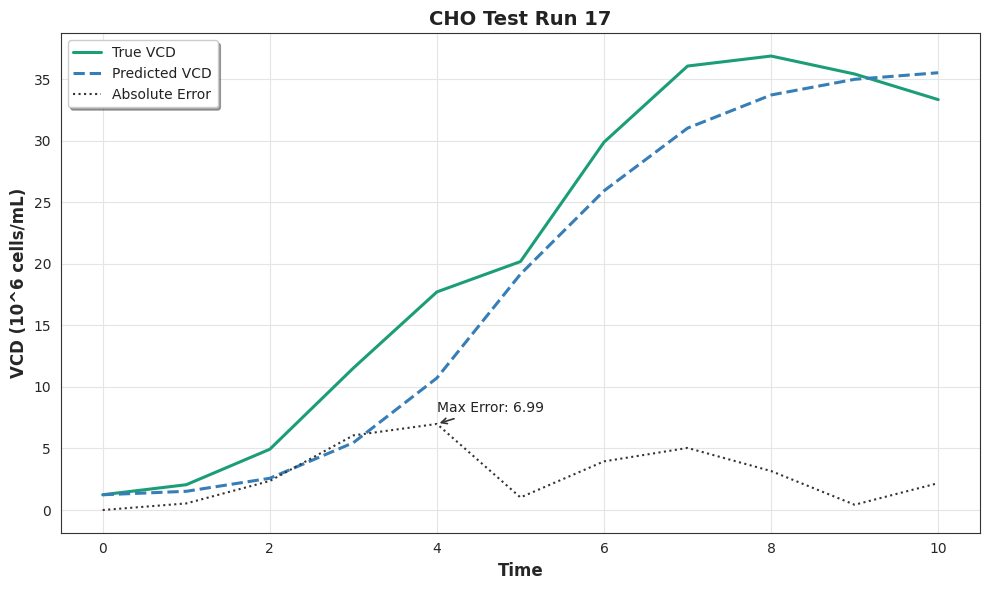

In [ ]:
for i in range(n_samples):
    mask = y_test[i] != -2.0
    time_points = np.arange(sum(mask))
    true_vals = vcd_true_original[i][mask]
    pred_vals = vcd_pred_original[i][mask]
    abs_error = np.abs(true_vals - pred_vals)

    plt.figure(figsize=(10, 6))

    plt.plot(
        time_points, true_vals,
        label='True VCD',
        linewidth=2.2,
        color=colours["line_exp"]
    )

    plt.plot(
        time_points, pred_vals,
        label='Predicted VCD',
        linewidth=2.2,
        linestyle='--',
        color=colours["line_model"]
    )

    plt.plot(
        time_points, abs_error,
        label='Absolute Error',
        color=colours["axes"],
        linestyle=':'
    )

    max_idx = np.argmax(abs_error)
    plt.annotate(
        f"Max Error: {abs_error[max_idx]:.2f}",
        xy=(time_points[max_idx], abs_error[max_idx]),
        xytext=(time_points[max_idx], abs_error[max_idx] + 1),
        arrowprops=dict(arrowstyle="->", color=colours["axes"], lw=1.2),
        fontsize=10,
        color=colours["text"]
    )

    plt.title(f'CHO Test Run {i+1}', fontsize=14, fontweight='bold')
    plt.xlabel('Time', fontsize=12, fontweight='bold')
    plt.ylabel('VCD (10^6 cells/mL)', fontsize=12, fontweight='bold')
    plt.legend(fontsize=10, frameon=True, shadow=True, loc='best')
    plt.grid(True)
    plt.gca().set_facecolor(colours["background"])
    plt.tight_layout()

In [ ]:
print("True VCDn", vcd_true_original[i].flatten())
print("Predicted VCD", vcd_pred_original[i].flatten())


True VCDn [  1.23928526   2.05534232   4.93482352  11.52754016  17.71280582
  20.17637     29.87287787  36.05583477  36.86919946  35.4075285
  33.32910097 -23.71793418 -23.71793418 -23.71793418]
Predicted VCD [ 1.23928526  1.51981832  2.57784045  5.46729702 10.72148819 19.15413254
 25.92212926 31.01358846 33.70488263 34.97886554 35.51277157 35.51277157
 35.51277369 35.51277369]


**Global average error:**

In [ ]:
mask = y_test != -2.0

masked_true = vcd_true_original[mask]
masked_pred = vcd_pred_original[mask]

mse = mean_squared_error(masked_true, masked_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(masked_true, masked_pred)

print(f"Test RMSE= {rmse:.2f} 10^6 cells/mL")
print(f"Test MAE= {mae:.2f} 10^6 cells/mL")

Test RMSE= 3.30 10^6 cells/mL
Test MAE= 2.31 10^6 cells/mL


In [ ]:
rmse_p = (rmse / vcd_true_original.max()) * 100
mae_p = (mae / vcd_true_original.max()) * 100

print(f"RMSE = {rmse_p:.1f}% of the VCD max in test set.")
print(f"MAE = {mae_p:.1f}% of the VCD max in test set.")

RMSE = 9.0% of the VCD max in test set.
MAE = 6.3% of the VCD max in test set.


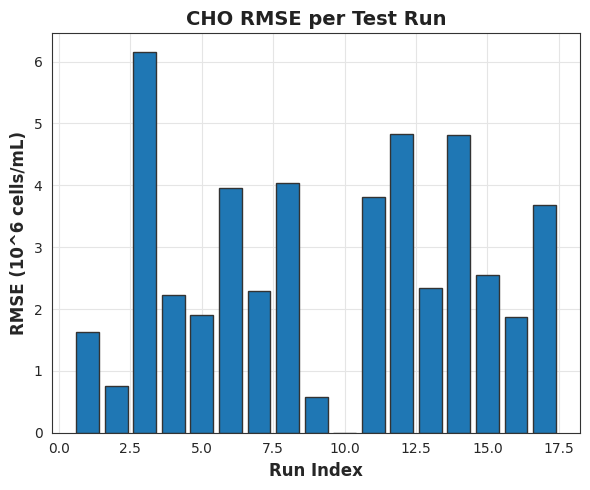

In [ ]:
rmse_per_run = []
mae_per_run = []

for i in range(n_samples):
    mask = y_test[i] != -2.0
    true_vals = vcd_true_original[i][mask]
    pred_vals = vcd_pred_original[i][mask]

    rmse_i = np.sqrt(np.mean((true_vals - pred_vals)**2))
    mae_i = np.mean(np.abs(true_vals - pred_vals))

    rmse_per_run.append(rmse_i)
    mae_per_run.append(mae_i)

plt.figure(figsize=(6,5))
plt.bar(np.arange(1, n_samples+1), rmse_per_run, edgecolor=colours['axes'])
plt.title('CHO RMSE per Test Run', fontsize=14, fontweight='bold')
plt.xlabel('Run Index', fontsize=12, fontweight='bold')
plt.ylabel('RMSE (10^6 cells/mL)', fontsize=12, fontweight='bold')
plt.grid(True)
plt.tight_layout()

In [ ]:
group = test_df.groupby(group_cols).first().reset_index()

errors = []
for i in range(len(vcd_true_original)):
    true_vals = vcd_true_original[i]
    pred_vals = vcd_pred_original[i]
    mask = y_test[i] != -2.0
    mae = mean_absolute_error(true_vals[mask], pred_vals[mask])
    rmse = np.sqrt(np.mean((true_vals[mask] - pred_vals[mask]) ** 2))


    errors.append({'group_index': i, 'MAE': mae, 'RMSE': rmse})

error_df = pd.DataFrame(errors)

group_with_error = pd.concat([group, error_df], axis=1)

summary = group_with_error.groupby('group_volume')[['MAE', 'RMSE']].mean().sort_values('MAE')

print(summary)

                   MAE      RMSE
group_volume                    
14.0          0.429146  0.584268
250.0         1.224082  1.622192
50.0          1.643518  1.905141
2000.0        2.341248  3.046575
3.0           2.377653  2.929003
5000.0        2.527763  3.303327


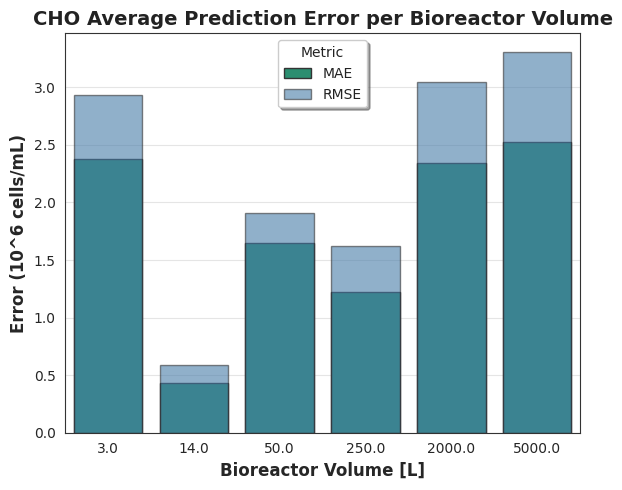

In [ ]:
plt.figure(figsize=(6, 5))

sns.barplot(data=summary.reset_index(), x='group_volume', y='MAE',
            color=colours['line_exp'], edgecolor=colours['axes'], label='MAE')
sns.barplot( data=summary.reset_index(), x='group_volume', y='RMSE',
            color=colours['line_model'], edgecolor=colours['axes'], alpha=0.6, label='RMSE')

plt.title('CHO Average Prediction Error per Bioreactor Volume', fontsize=14, fontweight='bold')
plt.xlabel('Bioreactor Volume [L]', fontsize=12, fontweight='bold')
plt.ylabel('Error (10^6 cells/mL)', fontsize=12, fontweight='bold')
plt.legend(title='Metric', fontsize=10, frameon=True, shadow=True)
plt.grid(True, axis = 'y')
plt.tight_layout()

In [ ]:
model.save('model_main_study.keras')
files.download('model_main_study.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>